# **2270 - FINANCIAL MODELLING: GROUP ASSIGNMENT**
*Group: Pietro De Bernardi (69791), Andrea Gaudio (65808), Virginia Pecci (70824), Filippo Urbani (65847), Anna Chiara Pegoraro (68353), Sofia Campilli (71606)*

To efficiently manipulate data, perform numerical calculations, and visualize results, we will rely on a few core Python libraries commonly used in financial modelling:
- **NumPy**: used for numerical operations and array-based calculations.
- **Pandas**: used to handle structured data in a flexible DataFrame format.
- **Matplotlib**: used to create clear, publication-ready plots for the yield curve and portfolio sensitivity analysis.
- **Yfinance**: API to get financial data from yahoo.finance.com
- **QuantStats**: useful for performance evaluation.

These libraries are standard in financial modelling and are fully compatible with Google Colab.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
!pip install -q fredapi
from fredapi import Fred
!pip -q install quantstats
import quantstats as qs
from scipy.optimize import minimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 3.3 MB/s eta 0:00:00


--- FIRST METHOD (Unconstrained) ---
 Ticker   Weight
IWDA.AS  270.28%
IS3N.DE -465.57%
AGGH.MI  -23.28%
2B7S.DE  189.89%
 SGLN.L  128.68%
Expected return: 50.00%
Volatility:      23.90%
Sharpe ratio:    1.97
----------------------------------------

--- SECOND METHOD (Long only, with constraints) ---
 Ticker Weight
IWDA.AS 16.90%
IS3N.DE  5.00%
AGGH.MI 38.10%
2B7S.DE 30.00%
 SGLN.L 10.00%
Expected return: 8.73%
Volatility:      8.87%
Sharpe ratio:    0.65
----------------------------------------


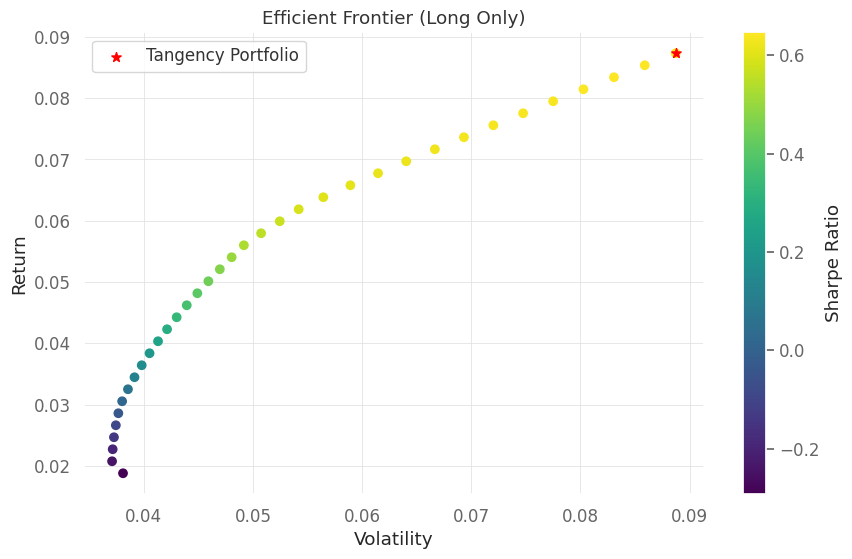


--- THIRD METHOD (Monte Carlo Simulation) ---
 Ticker Weight
IWDA.AS  3.03%
IS3N.DE  0.13%
AGGH.MI  1.56%
2B7S.DE 39.49%
 SGLN.L 55.78%
Expected return: 15.08%
Volatility:      9.04%
Sharpe ratio:    1.34
----------------------------------------


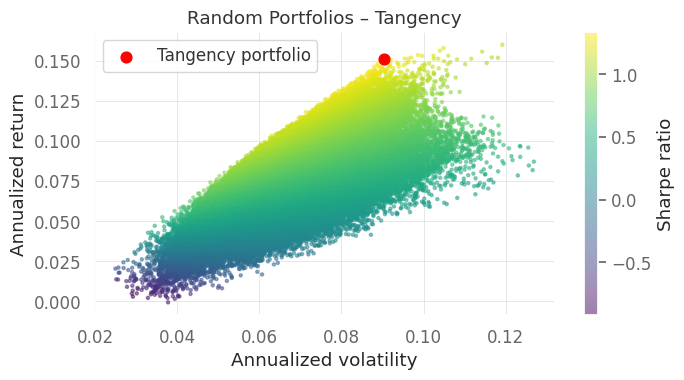

In [ ]:
# Ticker of selected ETFs
tickers = ['IWDA.AS', 'IS3N.DE', 'AGGH.MI', '2B7S.DE', 'SGLN.L']

# Import data from yahoo.finance.com
df = yf.download(tickers, start='2017-01-01', interval='1mo', auto_adjust=False, progress=False)

# Use adjusted close or close
if 'Adj Close' in df.columns:
    prices = df['Adj Close'].copy()
else:
    prices = df['Close'].copy()
prices = prices.dropna()

# Import risk free from yahoo.finance.com
fred = Fred(api_key= '...') # insert you API key here
bund_data = fred.get_series('IRLTLT01DEM156N')
latest_yield_percent = bund_data.iloc[-1]
rf_rate = latest_yield_percent / 100

# Compute monthly returns
returns = np.log(prices) - np.log(prices.shift(1))
returns = returns.dropna()

# Estimate mean & variance (annualized)
mu = 12*np.array(returns.mean())
s = np.sqrt(12)*np.array(returns.std())
sigma = 12*np.cov(returns, rowvar=False)

# ---- FIRST METHOD (Mean-Variance Optimization, without long only constraint) ----

# Define optimal weight function
def find_optimal_weights(r_p, mu, sigma):
    N = len(mu)
    A = np.zeros((N+2,N+2))
    A[:N,:N] = 2*sigma
    A[:N,N] = mu
    A[:N,N+1] = np.ones(N)
    A[N,:N] = mu
    A[N+1,:N] = np.ones(N)
    b = np.zeros((N+2,1))
    b[N] = r_p
    b[N+1] = 1
    sol = np.linalg.solve(A,b)
    return sol[:N].flatten() # Ensure 1D output

# Find optimal weight (classical method) for a given starting level of return
r_p = 0.10
w = find_optimal_weights(r_p, mu, sigma)

# Find the variance of the portfolio
vol = np.sqrt(w.transpose() @ sigma @ w)

# Create the efficient frontier
ptf_rets = np.linspace(0.001, 0.50, 100)
weights = np.array([find_optimal_weights(r,mu,sigma) for r in ptf_rets])

# Find the volatility for each set of weights
def vol_calc(w, sigma):
  return np.sqrt(w.transpose() @ sigma @ w)
ptf_vols = np.array([vol_calc(w,sigma) for w in weights])

# Find the efficient frontier and CAL slopes
frontier_slopes = np.diff(ptf_rets) / np.diff(ptf_vols)
cal_slopes = (ptf_rets - rf_rate) / ptf_vols

# Find the weights of the Tangency portfolio
tangency_idx = np.argmax(cal_slopes) # Maximize SR directly
tan_sharpe_ratio = cal_slopes[tangency_idx]
tan_exp_ret = ptf_rets[tangency_idx]
tan_vol = ptf_vols[tangency_idx]

# Output
w_tangency_1 = pd.DataFrame({'Ticker': tickers, 'Weight': weights[tangency_idx]})
w_tangency_1['Weight'] = w_tangency_1['Weight'].apply(lambda x: f"{x:.2%}")
print('--- FIRST METHOD (Unconstrained) ---')
print(w_tangency_1.to_string(index=False))
print(f'Expected return: {tan_exp_ret:.2%}')
print(f'Volatility:      {tan_vol:.2%}')
print(f'Sharpe ratio:    {tan_sharpe_ratio:.2f}')
print('-' * 40)

# ---- SECOND METHOD (Mean-Variance Optimization, with long only constraint)

# Define the optimization function
def find_optimal_weights_long_only(target_return, mu, sigma):
    num_assets = len(mu)
    def portfolio_variance(w):
        return w.T @ sigma @ w
    # Introduce constraints
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}, # 100% portfolio constraint
        {'type': 'eq', 'fun': lambda w: w @ mu - target_return} # Portfolio return same as target
    )
    bounds = (
    (0.10, 0.50), # IWDA: Min 10%, Max 50%
    (0.05, 0.30), # IS3N: Min 5%, Max 30%
    (0.10, 0.40), # AGGH: Min 10%, Max 40%
    (0.05, 0.30), # 2B7S: Min 5%, Max 30%
    (0.02, 0.10)  # SGLN: Min 2%, Max 10%)
    )

    # Starting point (equally weighted)
    initial_guess = np.ones(num_assets) / num_assets
    # Optimization
    result = minimize(portfolio_variance, initial_guess, method='SLSQP',
                      bounds=bounds, constraints=constraints)
    return result.x if result.success else None

# Define a range of possibile returns
min_ret = min(mu)
max_ret = max(mu)
ptf_rets = np.linspace(min_ret, max_ret * 0.99, 100)

# Create empty lists for the portfolio weights, returns and volatilites
weights_list = []
valid_rets = []
vols_list = []

# Esecute the optimization and find portfolio metrics
for r in ptf_rets:
    w = find_optimal_weights_long_only(r, mu, sigma)
    if w is not None:
        weights_list.append(w)
        vol = np.sqrt(w.T @ sigma @ w)
        vols_list.append(vol)
        valid_rets.append(r)

# Fill the previous lists
weights = np.array(weights_list)
ptf_vols = np.array(vols_list)
ptf_rets = np.array(valid_rets)

# Compute Sharpe Ratios
sharpe_ratios = (ptf_rets - rf_rate) / ptf_vols

# Find the index of Tangecy portfolio (max Sharpe Ratiio)
tangency_idx = np.argmax(sharpe_ratios)

# Find Tangency portfolio metrics
tan_sharpe_ratio = sharpe_ratios[tangency_idx]
tan_exp_ret = ptf_rets[tangency_idx]
tan_vol = ptf_vols[tangency_idx]

# Output
w_tangency_2 = pd.DataFrame({'Ticker': tickers, 'Weight': weights[tangency_idx]})
w_tangency_2['Weight'] = w_tangency_2['Weight'].apply(lambda x: f"{x:.2%}")
print('\n--- SECOND METHOD (Long only, with constraints) ---')
print(w_tangency_2.to_string(index=False))
print(f'Expected return: {tan_exp_ret:.2%}')
print(f'Volatility:      {tan_vol:.2%}')
print(f'Sharpe ratio:    {tan_sharpe_ratio:.2f}')
print('-' * 40)
plt.figure(figsize=(10, 6))
plt.scatter(ptf_vols, ptf_rets, c=sharpe_ratios, cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(tan_vol, tan_exp_ret, c='red', s=50, marker='*', label='Tangency Portfolio')
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.title('Efficient Frontier (Long Only)')
plt.legend()
plt.show()

# ---- THIRD METHOD (Monte Carlo Simulation) ----

# Determine the number of randomization
n_assets = len(tickers)
n_portfolios = 100_000  # you can reduce if Colab is slow

# Create empty matrix and lists for the portfolio weights, returns, volatilites and Sharpe Ratios
all_weights = np.zeros((n_portfolios, n_assets))
ptf_ret = np.zeros(n_portfolios)
ptf_vol = np.zeros(n_portfolios)
ptf_sharpe = np.zeros(n_portfolios)

# Fix the seed
np.random.seed(42)

for i in range(n_portfolios):
    w = np.random.random(n_assets) # long only constraint
    w = w / w.sum() # 100% portfolio constraint
    all_weights[i, :] = w

    # Compute portfolio metrics
    r = w @ mu
    v = np.sqrt(w @ sigma @ w)
    ptf_ret[i] = r
    ptf_vol[i] = v
    ptf_sharpe[i] = (r - rf_rate) / v

# Find index of maximum Sharpe ratio portfolio
max_idx = np.argmax(ptf_sharpe)

# Find Tangency portfolio metrics
w_maxsharpe = all_weights[max_idx, :]
ret_maxsharpe = ptf_ret[max_idx]
vol_maxsharpe = ptf_vol[max_idx]
sharpe_max = ptf_sharpe[max_idx]

# Output
w_tangency_3 = pd.DataFrame({'Ticker': tickers, 'Weight': w_maxsharpe})
w_tangency_3['Weight'] = w_tangency_3['Weight'].apply(lambda x: f"{x:.2%}")
print('\n--- THIRD METHOD (Monte Carlo Simulation) ---')
print(w_tangency_3.to_string(index=False))
print(f'Expected return: {ret_maxsharpe:.2%}')
print(f'Volatility:      {vol_maxsharpe:.2%}')
print(f'Sharpe ratio:    {sharpe_max:.2f}')
print('-' * 40)
plt.figure(figsize=(7, 4))
plt.scatter(ptf_vol, ptf_ret, c=ptf_sharpe, cmap='viridis', s=5, alpha=0.5)
plt.colorbar(label="Sharpe ratio")
plt.scatter(vol_maxsharpe, ret_maxsharpe, c="red", s=60, label='Tangency portfolio')
plt.xlabel('Annualized volatility')
plt.ylabel('Annualized return')
plt.title('Random Portfolios – Tangency')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_898/2033217867.py:10: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


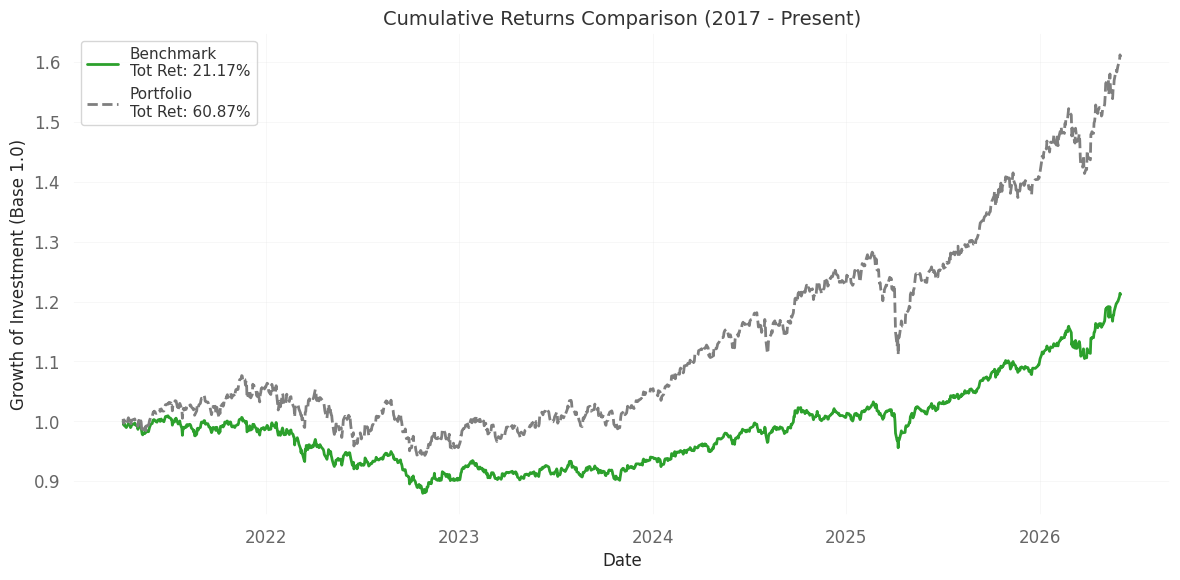

In [3]:
# Benchmark weights (60%/40%)
w_benchmark = np.array([0.60, 0, 0.40, 0, 0])

# Portfolio weights (optimized)
w_portfolio = weights[tangency_idx]

data = yf.download(tickers, start='2017-01-01', auto_adjust=False, progress=False)['Close']

# Compute daily returns
returns = data.pct_change().dropna()
port_ret_benchmark = returns.dot(w_benchmark)
port_ret = returns.dot(w_portfolio)

# Compute cumulative returns
cum_ret_benchmark = (1 + port_ret_benchmark).cumprod()
cum_ret = (1 + port_ret).cumprod()

# Compute total cumulative return
tot_ret_benchmark = cum_ret_benchmark.iloc[-1] - 1
tot_ret = cum_ret.iloc[-1] - 1

# Time Series Plot
plt.figure(figsize=(12, 6))
plt.plot(cum_ret_benchmark, label=f'Benchmark\nTot Ret: {tot_ret_benchmark:.2%}',
         color='#2ca02c', linewidth=2) # Verde
plt.plot(cum_ret, label=f'Portfolio\nTot Ret: {tot_ret:.2%}',
         color='#7f7f7f', linestyle='--', linewidth=2) # Grigio tratteggiato
plt.title('Cumulative Returns Comparison (2017 - Present)', fontsize=14)
plt.ylabel('Growth of Investment (Base 1.0)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Back testing (from 06-04-2021 to today)
portfolio_returns = returns.dot(w_portfolio)
qs.reports.metrics(portfolio_returns, mode='full', rf=rf_rate)


Parameter       Value
--------------  -------
Risk-Free Rate  3.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Strategy
-------------------------  ----------
Start Period               2021-04-06
End Period                 2026-06-03
Risk-Free Rate             3.0%
Time in Market             100.0%

Cumulative Return          60.87%
CAGR﹪                     9.46%

Sharpe                     0.68
Prob. Sharpe Ratio         87.49%
Smart Sharpe               0.67
Sortino                    0.95
Smart Sortino              0.94
Sortino/√2                 0.67
Smart Sortino/√2           0.66
Omega                      1.13

Max Drawdown               -13.42%
Max DD Date                2025-04-09
Max DD Period Start        2025-02-24
Max DD Period End          2025-07-25
Longest DD Days            815
Volatility (ann.)          9.65%
Calmar                     0.7
Skew                       -0.47
Kurtosis                   3.53
Ulcer Performance 